In [1]:
import math
import scipy
import numpy as np
import matplotlib.pyplot as plt

### Демонстрация метода Брента

КОПИЯ одной и той же функции brent. Дублируется в: zadachi_metody_minimuma.ipynb, метод Брента.ipynb, testy_i_skhodimost.ipynb.
При любой правке синхронизировать ВСЕ три копии — иначе таблица и выводы разойдутся.

In [2]:
def brent(f, a, b, eps=1e-3, max_iter=100):
    # a, b	границы текущего отрезка
    # x	лучшая точка (самое низкое f)
    # w	вторая по качеству точка
    # v	третья по качеству точка
    # u	новая точка-кандидат
    # d	шаг, сделанный в прошлый раз
    # e	шаг, сделанный перед d
    # c_gold = (3−√5)/2	константа золотого сечения ≈ 0.382

    c_gold = (3 - math.sqrt(5)) / 2 
    x = w = v = a + c_gold * (b - a)
    fx = fw = fv = f(x)
    d = 0
    e = 0
    func_calls = 1

    for iteration in range (max_iter):
        if (b - a) < eps:
            break

        u = None

        if e != 0 and v != w and w != x and v != x: #можно ли строить параболу?
            D1 = (fw - fx) / (w - x)
            D2 = (fv - fw) / (v - w)
            A = (D2 - D1) / (v - x)

            if abs(A) > 1e-12: # если парабола не вырождается в прямую, ищем вершину
                apex = (x + w) / 2 - D1 / (2 * A)
                if a < apex < b and abs(apex - x) < 0.5 * abs(e):
                    u = apex    #тогда вершина кандидат на новую лучшую точку

        if u is None: # если парабола не подошла или не получилась, пробуем золотое сечение
            if x < (a + b) / 2: #если в левой половине, шагаем вправо
                u = x + (b - x) * c_gold
            else: 
                u = x - (x - a) * c_gold

        e = d
        d = u - x   #величина текущего шага
        fu = f(u)
        func_calls += 1

        if fu <= fx:    #если новая точка лучше x
            if u >= x:
                a = x
            else:
                b = x
            v, fv = w, fw
            w, fw = x, fx
            x, fx = u, fu
        else:   #если хуже x
            if u >= x:
                b = u
            else:
                a = u
                
            #но если она улчше w или v
            if fu <= fw or w == x: 
                v, fv = w, fw
                w, fw = u, fu
            elif fu <= fv or v == x or v == w:
                v, fv = u, fu

    return x, fx, func_calls, iteration 
                                                

In [3]:
def f1(x):
    return abs(x)

def f2(x):
    return (x - 3) ** 2 + 10 * x

x, fx, func_calls, iteration = brent(f1, -5, 5, eps=1e-3, max_iter=100)
print(f"{x:.4f}; {fx:.4f}")

x, fx, func_calls, iteration = brent(f2, 0, 4, eps=1e-3, max_iter=100)
print(f"{x:.4f}; {fx:.4f}")

-0.0000; 0.0000
0.0004; 9.0017


## Пошаговая визуализация: Брент на |x|

f(x) = |x| на отрезке [−5; 5] — V-образная функция с острой вершиной в 0.
Парабола в такой вершине «прыгает» и не сходится сама по себе, но Брент сходится к 0 благодаря страховке золотым сечением и сужению отрезка.

Обозначения на графике: **синие** точки — шаг золотого сечения, **оранжевые** — шаг параболы;
**o** — точка принята (стала лучшей x), **x** — отвергнута (выше текущего x); номер — итерация.
Слева весь процесс, справа зум у дна: видно, как вершины параболы «прыгают» слева от 0.


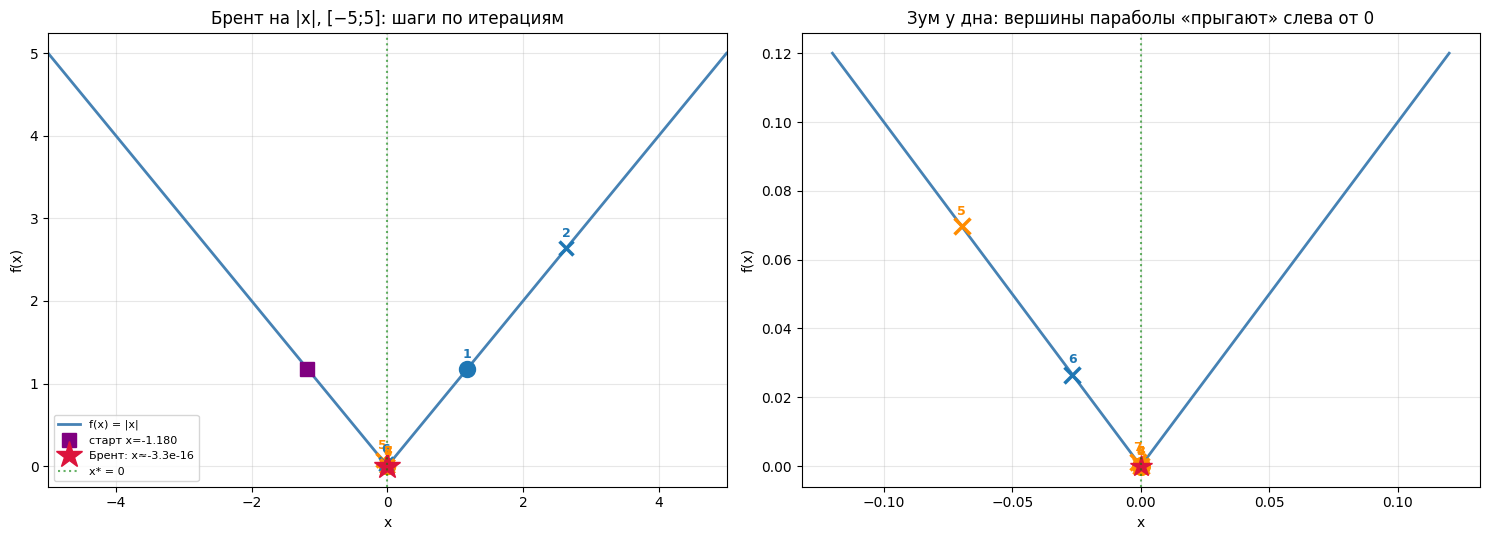

x = -3.33e-16 | fx = 3.33e-16 | вызовов f = 9 | итераций = 8
it тип             u       fu принят |   ширина
 0 золотое    1.1803   1.1803     да |   6.1803
 1 золотое    2.6393   2.6393    нет |   3.8197
 2 парабола   0.0000   0.0000     да |   2.3607
 3 парабола  -0.0000   0.0000     да |   1.1803
 4 парабола  -0.0697   0.0697    нет |   0.0697
 5 золотое   -0.0266   0.0266    нет |   0.0266
 6 парабола  -0.0013   0.0013    нет |   0.0013
 7 парабола  -0.0001   0.0001    нет |   0.0001

Чистая парабола на |x|, отрезок [-3;5]:
  первые шаги: [0.333, -0.444, 0.035, -0.026, -0.027, 0.0]
  финал: метод застрял на 0.351 вместо 0


In [4]:

def brent_trace(f, a, b, eps=1e-3, max_iter=100):
    """Брент с журналом шагов. Возвращает x, fx, число вызовов, число итераций и список шагов."""
    c_gold = (3 - math.sqrt(5)) / 2
    x = w = v = a + c_gold * (b - a)
    fx = fw = fv = f(x)
    d = 0
    e = 0
    func_calls = 1
    log = []

    for iteration in range(max_iter):
        if (b - a) < eps:
            break

        u = None
        kind = None
        apex = None
        if e != 0 and v != w and w != x and v != x:
            D1 = (fw - fx) / (w - x)
            D2 = (fv - fw) / (v - w)
            A = (D2 - D1) / (v - x)
            if abs(A) > 1e-12:
                apex = (x + w) / 2 - D1 / (2 * A)
                if a < apex < b and abs(apex - x) < 0.5 * abs(e):
                    u = apex
                    kind = 'парабола'

        if u is None:
            if x < (a + b) / 2:
                u = x + (b - x) * c_gold
            else:
                u = x - (x - a) * c_gold
            kind = 'золотое'

        e = d
        d = u - x
        fu = f(u)
        func_calls += 1
        accepted = fu <= fx

        if fu <= fx:
            if u >= x:
                a = x
            else:
                b = x
            v, fv = w, fw
            w, fw = x, fx
            x, fx = u, fu
        else:
            if u >= x:
                b = u
            else:
                a = u
            if fu <= fw or w == x:
                v, fv = w, fw
                w, fw = u, fu
            elif fu <= fv or v == x or v == w:
                v, fv = u, fu

        log.append(dict(it=iteration, a=a, b=b, x=x, kind=kind, u=u,
                       fu=fu, apex=apex, accepted=accepted, bw=b-a))

    return x, fx, func_calls, iteration, log


def draw_abs_steps():
    f = lambda x: abs(x)
    x, fx, fc, iters, log = brent_trace(f, -5, 5, eps=1e-3)

    fig, (ax, axz) = plt.subplots(1, 2, figsize=(15, 5.5))
    colors = {'золотое': '#1f77b4', 'парабола': 'darkorange'}

    xs = np.linspace(-5, 5, 800)
    ax.plot(xs, [f(v) for v in xs], 'steelblue', lw=2, label='f(x) = |x|')

    x0 = -5 + (3 - math.sqrt(5)) / 2 * 10
    ax.plot(x0, f(x0), 's', color='purple', ms=10, label=f'старт x={x0:.3f}')

    for row in log:
        c = colors[row['kind']]
        m = 'o' if row['accepted'] else 'x'
        ax.plot(row['u'], f(row['u']), m, color=c, ms=10, mew=2.5)
        ax.annotate(str(row['it'] + 1), (row['u'], f(row['u'])),
                    textcoords='offset points', xytext=(0, 8), ha='center',
                    fontsize=9, color=c, fontweight='bold')
    ax.plot(x, fx, '*', color='crimson', ms=20,
            label=f'Брент: x≈{x:.1e}')
    ax.axvline(0, color='green', ls=':', alpha=0.6, label='x* = 0')
    ax.set_xlim(-5, 5)
    ax.set_title('Брент на |x|, [−5;5]: шаги по итерациям')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    xsz = np.linspace(-0.12, 0.12, 600)
    axz.plot(xsz, [f(v) for v in xsz], 'steelblue', lw=2)
    for row in log:
        if not (-0.12 <= row['u'] <= 0.12):
            continue
        c = colors[row['kind']]
        m = 'o' if row['accepted'] else 'x'
        axz.plot(row['u'], f(row['u']), m, color=c, ms=11, mew=2.5)
        axz.annotate(str(row['it'] + 1), (row['u'], f(row['u'])),
                     textcoords='offset points', xytext=(0, 8), ha='center',
                     fontsize=9, color=c, fontweight='bold')
    axz.plot(x, fx, '*', color='crimson', ms=16)
    axz.axvline(0, color='green', ls=':', alpha=0.6)
    axz.set_title('Зум у дна: вершины параболы «прыгают» слева от 0')
    axz.set_xlabel('x'); axz.set_ylabel('f(x)')
    axz.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'x = {x:.2e} | fx = {fx:.2e} | вызовов f = {fc} | итераций = {iters}')
    print(f'{"it":>2} {"тип":<8} {"u":>8} {"fu":>8} {"принят":>6} | {"ширина":>8}')
    for r in log:
        print(f"{r['it']:>2} {r['kind']:<8} {r['u']:>8.4f} {r['fu']:>8.4f} "
              f"{'да' if r['accepted'] else 'нет':>6} | {r['bw']:>8.4f}")


draw_abs_steps()


# Для сравнения: чистая парабола на |x| с асимметричным отрезком [-3;5]
# (тот самый случай, где она прыгает в ~0.33 и застревает)
def parabolic_hist(f, a, b, eps=1e-3, max_iter=50):
    c = (a + b) / 2
    fa, fb, fc = f(a), f(b), f(c)
    if fc > fa or fc > fb:
        return None
    x1, x2, x3 = a, c, b
    f1, f2, f3 = fa, fc, fb
    hist = []
    for it in range(max_iter):
        D1 = (f2 - f1) / (x2 - x1)
        D2 = (f3 - f2) / (x3 - x2)
        A = (D2 - D1) / (x3 - x1)
        if abs(A) < 1e-12:
            break
        xn = (x1 + x2) / 2 - D1 / (2 * A)
        hist.append(xn)
        if abs(xn - x2) < eps:
            break
        fn = f(xn)
        pts = [(x1, f1), (x2, f2), (x3, f3), (xn, fn)]
        pts.sort(key=lambda p: p[0])
        pts.remove(max(pts, key=lambda p: p[1]))
        x1, f1 = pts[0]; x2, f2 = pts[1]; x3, f3 = pts[2]
    return hist


h = parabolic_hist(lambda x: abs(x), -3, 5, eps=1e-3)
print('\nЧистая парабола на |x|, отрезок [-3;5]:')
print('  первые шаги:', [round(v, 3) for v in h[:6]])
print('  финал: метод застрял на', round(h[-1], 3), 'вместо 0')


#### Сравнение метода Брента нашей реализации с scipy.optimize.minimize_scalar 

In [5]:
from scipy.optimize import minimize_scalar

def f_10(r):
    return -(6 * r - (2 + math.pi / 2) * r ** 2)

res = minimize_scalar(f_10, method='bounded', bounds=(0.1, 1.1))
print(res)

 message: Solution found.
 success: True
  status: 0
     fun: -2.520446190802008
       x: 0.8401487302673352
     nit: 6
    nfev: 6


In [6]:
x_star = 6 / (4 + math.pi)

res = minimize_scalar(f_10, method='bounded', bounds=(0.1, 1.1),
                      options={'xatol': 1e-3, 'disp': 3})

x_mine, f_mine, calls_mine, it_mine = brent(f_10, 0.1, 1.1, eps=1e-3)

print("аналитика       :", x_star)
print("scipy           :", res.x, "| вызовов:", res.nfev)
print("мой Брент       :", x_mine, "| вызовов:", calls_mine)

 
 Func-count     x          f(x)          Procedure
    1       0.481966     -2.06233        initial
    2       0.718034      -2.4672        golden
    3       0.863932     -2.51843        golden
    4       0.840149     -2.52045        parabolic
    5       0.840482     -2.52045        parabolic
    6       0.839815     -2.52045        parabolic

Optimization terminated successfully;
The returned value satisfies the termination criteria
(using xtol =  0.001 )
аналитика       : 0.840148730267336
scipy           : 0.8401487302673352 | вызовов: 6
мой Брент       : 0.8401487302673352 | вызовов: 11


Сверка с scipy.optimize.minimize_scalar (метод bounded, xatol=1e-3) на задаче 10: мой Брент — 11 вызовов, scipy — 6 вызовов. Обе точки совпали с аналитическим ответом 6/(4+π). Разница объясняется тем, что в моей реализации после попадания в окрестность минимума (вызов 4–5) переключается обратно на золотое сечение чтобы гарантированно сузить отрезок до `b - a < eps`. Затем он снова пробует параболу.


При xatol = 1e-5 (по умолчанию) и 1e-3 scipy делает одни и те же 6 вызовов, что доказывает, что дело в шагах.